# Спектральный анализ ЭЭГ данных, FFT

В этом ноутбуке мы познакомимся поближе с такими темами, как:

- Быстрое преобразование Фурье (FFT)
- Плотность спектральной мощности (PSD)
- Базовые частотные признаки
- Aliasing, методы борьбы

В конце ноутбука будет конспект по всем темам с полезными ссылками для дополнительного чтения

---

### 0. Загрузка данных

In [ ]:
!pip install mne==1.11.0 >> logs.txt

In [ ]:
import mne
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os

%matplotlib inline

In [ ]:
# Путь к sample-датасету (если данных нет, они автоматически скачаются)
sample_data_folder = mne.datasets.sample.data_path()
raw_path = os.path.join(
    sample_data_folder,
    "MEG",
    "sample",
    "sample_audvis_raw.fif",
)

In [ ]:
raw = mne.io.read_raw_fif(raw_path, preload=True).crop(tmax=60)

### 1. Быстрое преобразование Фурье (FFT)

**Преобразование Фурье (1807 год)** — это метод, который переводит сигнал из временной области в частотную и показывает, какие синусоиды входят в его состав

Проще говоря, сложный сигнал представляют как сумму косинусов и синусов с разными частотами, амплитудами и фазами.

Для ЭЭГ это особенно полезно, потому что ритмы мозга часто удобнее анализировать именно в частотной области, а не только по форме сигнала во времени



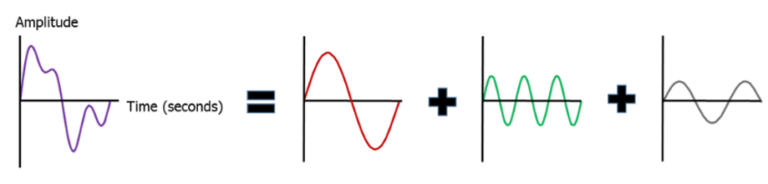

Источник: [CMI Brain Research](https://cmi.to/%D0%BC%D0%B5%D1%82%D0%BE%D0%B4%D1%8B/%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7-%D1%84%D1%83%D1%80%D1%8C%D0%B5/)

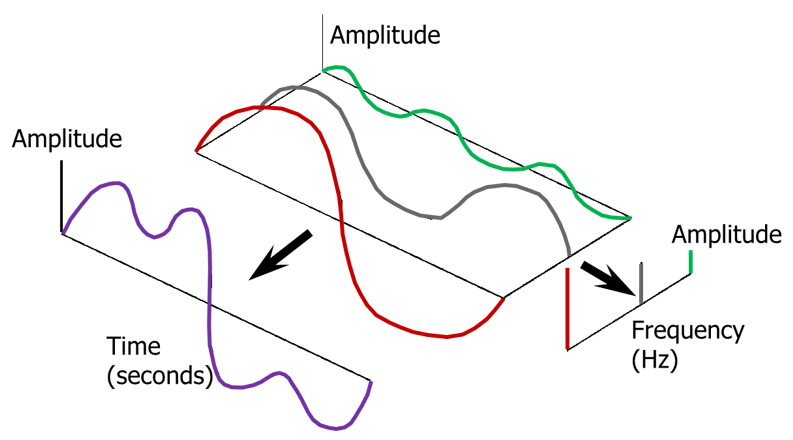

Источник: [CMI Brain Research](https://cmi.to/%D0%BC%D0%B5%D1%82%D0%BE%D0%B4%D1%8B/%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7-%D1%84%D1%83%D1%80%D1%8C%D0%B5/)

**Быстрое преобразование Фурье (FFT, 1965 год)** — это быстрый алгоритм вычисления дискретного преобразования Фурье. Вместо `O(N²)` операций делает `O(N·logN)`


In [ ]:
from scipy.fft import fft, fftfreq, rfft, rfftfreq

# Параметры сигнала (как в реальном ЭЭГ)
fs = 256
duration = 4
t = np.arange(0, duration, 1/fs)

# Синтетический ЭЭГ:

alpha = 2 * np.sin(2 * np.pi * 10 * t)
beta = 5 * np.sin(2 * np.pi * 20 * t)
noise = 2 * np.random.randn(len(t))

plt.figure(figsize=(12, 4))
plt.plot(t[:1000], beta[:1000], label='бета (20 Гц)')
plt.plot(t[:1000], noise[:1000], label='шум')
plt.plot(t[:1000], alpha[:1000], label='альфа (10 Гц)')
plt.legend()
plt.title('Синтетический EEG сигнал (время)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда (мкВ)')
plt.show()


In [ ]:
eeg_signal = (alpha + beta + noise)

plt.figure(figsize=(12, 4))
plt.plot(t[:1000], eeg_signal[:1000])
plt.title('Синтетический ЭЭГ сигнал из суммы альфы, беты и шума')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда (мкВ)')
plt.show()

In [ ]:
N = len(eeg_signal)

# FFT для вещественного сигнала
fft_real = rfft(eeg_signal)
#fft_complex = fft(eeg_signal)

# Частотная ось
freqs = rfftfreq(N, 1/fs)
#freqs_complex = fftfreq(N, 1/fs)

# Амплитудный спектр
amplitude = 2 * np.abs(fft_real) / N

plt.figure(figsize=(12, 4))
plt.plot(freqs[:N], amplitude[:N])
plt.title('Спектр мощности ЭЭГ (FFT)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.xlim(0, 50)
plt.xlim(-50, 50)
plt.grid(True, alpha=0.3)
plt.show()


А теперь поработаем с реальными ЭЭГ данными

In [ ]:
eeg_data, times = raw['EEG 001', :1000]  # 1000 отсчетов
fs_real = raw.info['sfreq']

plt.figure(figsize=(12, 4))
plt.plot(times[:500], eeg_data[0, :500] * 1e6)
plt.title('Реальный ЭЭГ канал (EEG 001)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда (мкВ)')
plt.show()

In [ ]:
# FFT реального ЭЭГ сигнала
N_real = len(eeg_data[0])
fft_eeg = rfft(eeg_data[0])
freqs_real = rfftfreq(N_real, 1/fs_real)
power_eeg = 2 * np.abs(fft_eeg) / N_real

plt.figure(figsize=(12, 4))
plt.semilogy(freqs_real, power_eeg)
plt.title('Спектр реального ЭЭГ')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.xlim(0, 50)
plt.grid(True, alpha=0.3)
plt.show()


#### Полезные ссылки:

- Быстрое преобразование Фурье на Вики: https://www.google.com/url?sa=t&source=web&rct=j&opi=89978449&url=https://en.wikipedia.org/wiki/Fast_Fourier_transform&ved=2ahUKEwjWt-nqkLSTAxV_mokEHYcFGVcQFnoECBoQAQ&usg=AOvVaw0EaKerfhvvjwlXOnO0nntY
- ДПФ и БПФ объяснение: https://habr.com/ru/companies/otus/articles/449996/
- Основы БПФ: https://supereyes.ru/articles/oscillograph/osnovy-bystrogo-preobrazovaniya-fure/?srsltid=AfmBOopAmEEDCdls1ubGonz1Tkiq0WZWIGKgzVKYXkLm0bF3LpIzM1f4

### 2. Плотность спектральной мощности (PSD)


**PSD (Power Spectral Density, Welch, 1967 год)** — показывает мощность сигнала на единицу частоты (например, мкВ²/Гц). В отличие от FFT (амплитуды), PSD даёт истинную мощность каждого ритма мозга. Он разбивает сигнал на куски, считает спектр для каждого и усредняет их. Это убирает шум и делает пики более четкими

Алгоритм Уэлча:
1. Делим сигнал на перекрывающиеся окна c 50% перекрытием
2. Считаем FFT внутри каждого окна
3. |FFT|², получаем мощность

Тут мощность сигнала пропорциональна квадрату его амплитуды. В ЭЭГ нас интересует именно энергия ритмов (например, насколько «силен» альфа-ритм), а фаза в стандартном спектральном анализе обычно отбрасывается

4. Нормируем результат на частоту дискретизации и параметры окна

5. Усредняем, получаем PSD

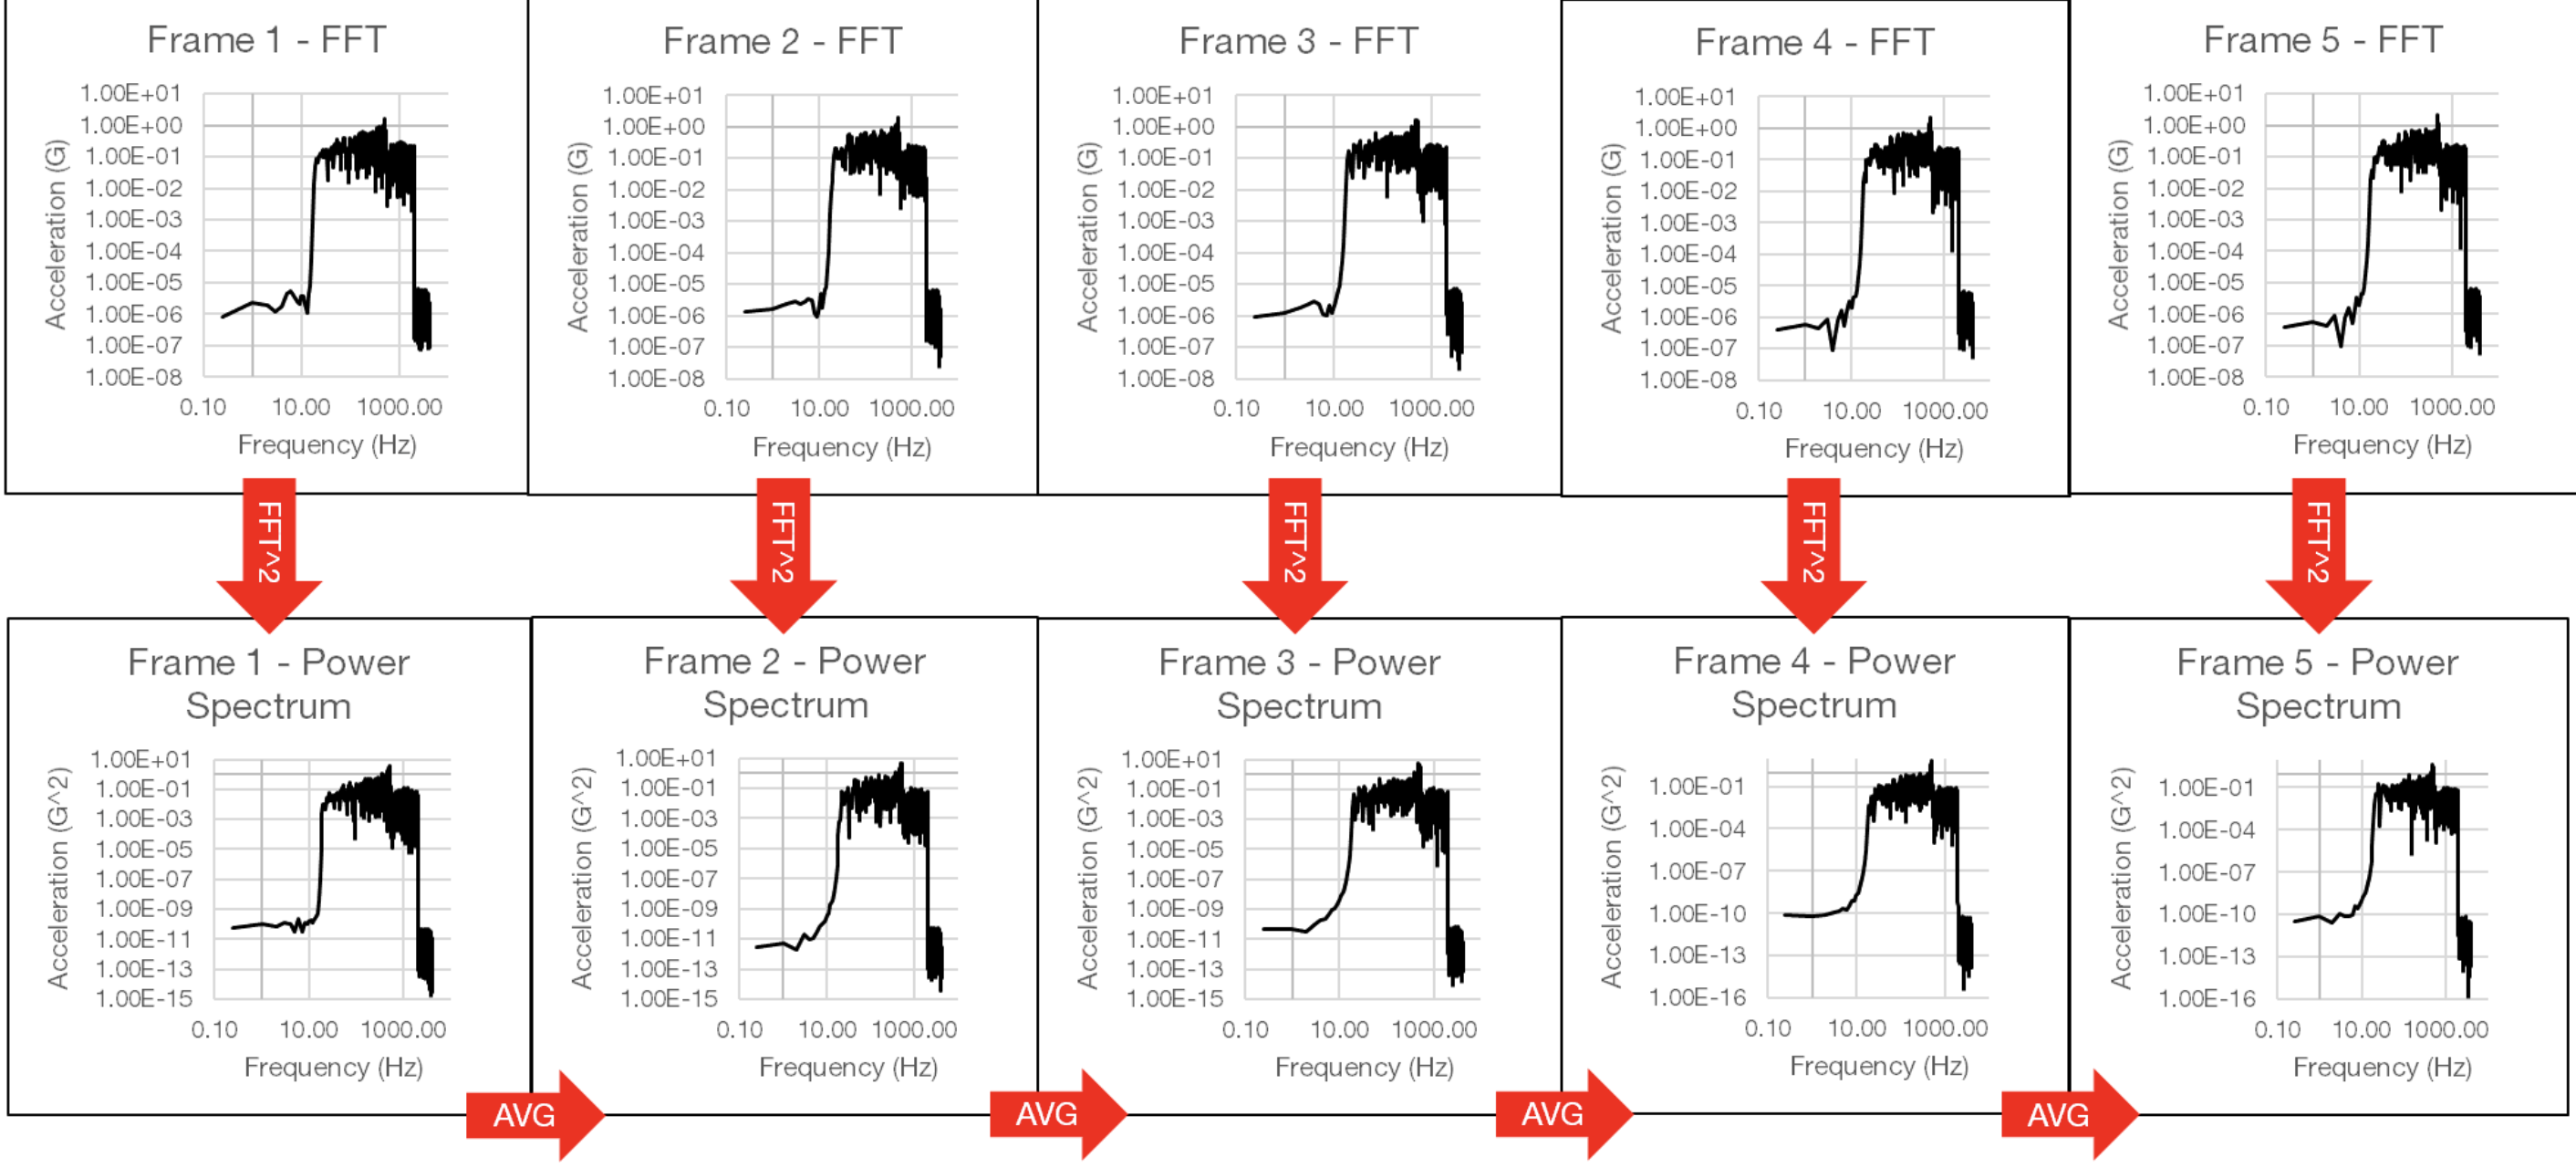

Источник: [Calculating PSD from a Time History File](https://vru.vibrationresearch.com/lesson/calculating-psd-time-history/)

In [ ]:
from scipy.signal import welch

# freqs: массив частот (Гц) для каждой точки спектра
# psd: массив значений мощности (Плотность Спектральной Мощности)
freqs, psd = welch(
    eeg_signal,          # исходный сигнал
    fs=fs,               # частота дискретизации (Гц)
    nperseg=fs,          # длина сегмента (окна) для усреднения (кол-во точек)
    noverlap=fs//2,      # количество точек для перекрытия между окнами
    nfft=2*fs            # размер БПФ (кол-во точек), задаёт шаг частоты (разрешение)
)

Поподробнее про `scipy.signal.welch`:

 https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.welch.html

In [ ]:
plt.figure(figsize=(12, 4))
plt.semilogy(freqs, psd)
plt.title('Плотность спектральной мощности синтетической ЭЭГ')
plt.xlabel('Частота (Гц)')
plt.ylabel('Мощность (В²/Гц)')
plt.xlim(0, 60)
plt.grid(True, alpha=0.3, which="both")

В mne для расчета PSD используется функция `compute_psd()`: https://mne.tools/stable/generated/mne.io.Raw.html#mne.io.Raw.compute_psd

Изначально используется метод Уэлча

In [ ]:
raw.info

In [ ]:
_ = raw.compute_psd(method='welch').plot(picks='eeg', exclude=['EEG 053'])

In [ ]:
_ = raw.compute_psd(method='welch', n_fft=fs*2, n_overlap=fs).plot(picks='eeg', exclude=['EEG 053'])

Помимо метода `Welch` есть метод `Multitaper` для расчета PSD, где сигнал умножается на несколько ортогональных окон (таперов Слятера), затем для каждого считается спектр и результаты усредняются с адаптивными весами. Подробнее:

https://mne.tools/stable/generated/mne.time_frequency.psd_array_multitaper.html

In [ ]:
_ = raw.compute_psd(method='multitaper').plot(picks='eeg', exclude=['EEG 053'])

Применение на практике

In [ ]:
_ = raw.copy(). \
  compute_psd(method='welch', fmin=0, fmax=80).plot(picks='eeg', exclude=['EEG 053'])

In [ ]:
_ = raw.copy().filter(l_freq=0.1, h_freq=40). \
  compute_psd(method='welch', fmin=0, fmax=80).plot(picks='eeg', exclude=['EEG 053'])

In [ ]:
_ = raw.copy().notch_filter(freqs=[50]). \
  compute_psd(method='welch', fmin=0, fmax=80).plot(picks='eeg', exclude=['EEG 053'])

#### Полезные ссылки:

- Welch`s method wiki: https://en.wikipedia.org/wiki/Welch%27s_method
- Про разницу FFT и PSD: https://vibrationresearch-com.translate.goog/blog/fft-psd-difference/?_x_tr_sl=en&_x_tr_tl=ru&_x_tr_hl=ru&_x_tr_pto=rq
- Функция `scipy.signal.welch`: https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.welch.html
- Функция compute_psd(): https://mne.tools/stable/generated/mne.io.Raw.html#mne.io.Raw.compute_psd
- PSD в MNE: https://mne.tools/stable/generated/mne.time_frequency.psd_welch.html
- Welch метод: https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.welch.html

### 3. Базовые частотные признаки

In [ ]:
duration = 10  # секунд
picks = mne.pick_types(raw.info, eeg=True)[:1]  # Первый канал
raw_segment = raw.copy().crop(tmin=0, tmax=duration).pick(picks)

# Переводим данные в мкВ
signal = raw_segment.get_data() * 1e6

#### Что можно посчитать
1. Амплитуду

Это одна из самых базовых характеристик EEG. Обычно смотрят:

- peak-to-peak amplitude — от пика до пика;
- максимальную амплитуду.

Для ЭЭГ амплитуда может лежать в пределах 10–100 мкВ, а в норме у здорового человека обычно не превышает 100–200 мкВ peak-to-peak

In [ ]:
print('Peak-to-peak (мкВ):', (np.max(signal) - np.min(signal)).round(2))
print('Макс амплитуда (мкВ):', np.max(np.abs(signal)).round(2))

2. Среднее значение сигнала

Показывает, есть ли смещение вверх или вниз.
После корректной обработки среднее обычно близко к нулю, но на сырых данных это полезно проверять

In [ ]:
print('Среднее (мкВ):', np.mean(signal).round(2))

3. Стандартное отклонение

Хорошая мера разброса сигнала вокруг среднего.
Если оно большое, сигнал более “неровный” и может содержать артефакты

In [ ]:
print('Std (мкВ):', np.std(signal).round(2))

Также еще можно считать:

4. RMS — среднеквадратичное значение

Одна из самых удобных общих мер “силы” сигнала.
Она хорошо отражает общую амплитуду колебаний и часто используется как простой признак

In [ ]:
print('RMS (мкВ):', np.sqrt(np.mean(signal**2)).round(2))



Частотные признаки — это характеристики сигнала, которые получают из его спектра. Для ЭЭГ чаще всего смотрят мощность в стандартных диапазонах: дельта, тета, альфа, бета и гамма. Такие признаки помогают количественно сравнивать активность мозга между каналами, условиями и испытуемыми.

Напомним, что в ЭЭГ выделяют следующие основные ритмы по частоте:
- Дельта-ритм (0,5–4 Гц) — глубокий сон, наркоз или патологические состояния.
- Тета-ритм (4–8 Гц) — поверхностный сон, глубокая релаксация или состояние «дремоты».
- Альфа-ритм (8–13 Гц) — состояние бодрствования в покое с закрытыми глазами.
- Бета-ритм (14–30 Гц) — активное бодрствование, концентрация внимания, когнитивная работа.
- Гамма-ритм (выше 30 Гц) — решение сложных задач, требующих максимального сосредоточения.

С помощью PSD можно посчитать, сколько мощности приходится на каждый диапазон частот. Если интегрировать PSD по полосе, мы получаем band power — мощность ритма в этой полосе, в этом диапазоне

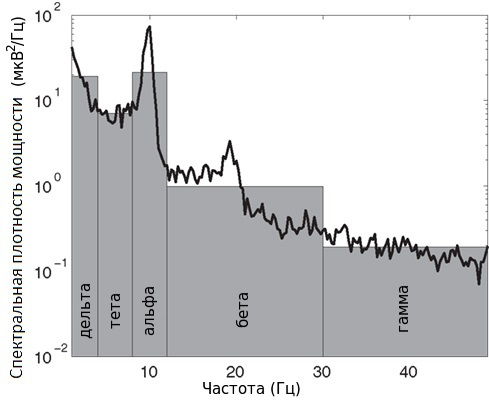

Источник: https://ru.wikipedia.org/wiki/Ритмы_головного_мозга

In [ ]:
raw.info["bads"] = []

psd = raw.compute_psd(picks='eeg', method='welch', fmin=0.5, fmax=45.0)
psd_data, freqs = psd.get_data(return_freqs=True)

bands = {
    'Delta': (0.5, 4),
    'Theta': (4, 8),
    'Alpha': (8, 13),
    'Beta': (14, 30),
    'Gamma': (30, 45) # ограничим до 45 Гц,
}

In [ ]:
print(len(psd.ch_names)) # n_channels
print(psd_data.shape) # (n_channels, n_freqs)
print(freqs.shape) # (n_freqs, )

In [ ]:
band_powers = {}

for band_name, (fmin, fmax) in bands.items():
    idx = (freqs >= fmin) & (freqs <= fmax)
    band_power = np.trapz(psd_data[:, idx], freqs[idx], axis=1)
    band_powers[band_name] = band_power

band_powers_df = pd.DataFrame(band_powers, index=psd.ch_names)
band_powers_df.head()

Полезно также посмотреть нормированную мощность: долю каждой полосы от общей мощности. Это помогает сравнивать каналы, когда абсолютные уровни сильно отличаются. Такой вариант часто удобнее для анализа и визуализации

In [ ]:
relative_band_powers = band_powers_df.div(band_powers_df.sum(axis=1), axis=0)
relative_band_powers.head()

#### Зачем это считать?

Например, мы хотим с вами детектировать закрыты или открыты глаза у человека в бодрствующем состоянии только лишь по активности мозга:

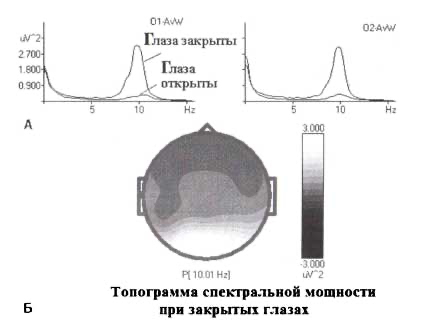

Источник: https://cmi.to/ритмы-ээг/альфа-ритмы/

Например, при алгоримтизации работы нейроинтерфейса в пардигме моторного воображения: у людей частота сенсомоторного ритма (мю-ритма) изменяется в диапазоне 9—13 Гц, который хорошо виден в состоянии покоя. При движении или представления движения происходит десинхронизация сенсомоторного ритма, т.е. мощность этого ритма падает

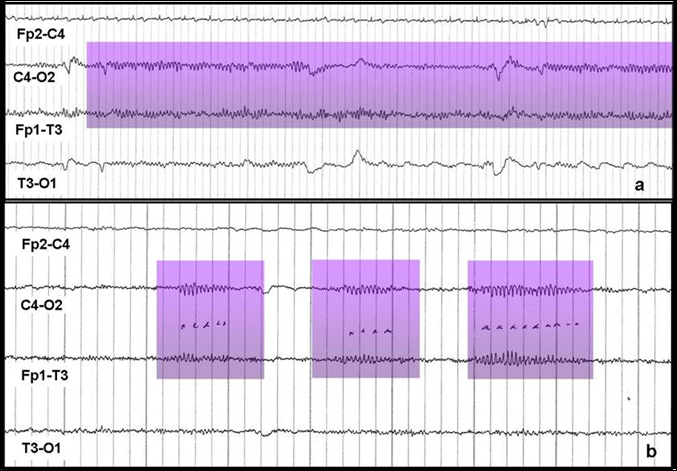

Источник: https://cmi.to/ритмы-ээг/альфа-ритмы/

#### Что еще можно посчитать?

1. Пиковая частота внутри диапазона

Это частота, на которой PSD максимальна в выбранной полосе.
Например, в альфа-диапазоне это может быть индивидуальная альфа-частота

2. Средняя мощность в диапазоне

Усреднение PSD по частотам внутри полосы.
Полезно, если не хочется интегрировать и нужна более простая характеристика

3. Отношения между полосами

Очень популярные признаки:

- alpha/beta

- theta/beta

- delta/alpha

Они часто лучше отражают состояние, чем отдельные полосы

4. Центр тяжести спектра

Это “средняя частота”, взвешенная по мощности. Показывает, где спектр в целом смещён: к низким или к высоким частотам

5. Спектральная энтропия

Показывает, насколько спектр “упорядочен” или “размазан”. Если спектр имеет один яркий пик — энтропия ниже, а если мощность распределена более равномерно — энтропия выше.

#### Полезные ссылки

- Про альфа- и мю- ритмы: https://cmi.to/ритмы-ээг/альфа-ритмы/
- Ритмы мозга: https://ru.wikipedia.org/wiki/%D0%A0%D0%B8%D1%82%D0%BC%D1%8B_%D0%B3%D0%BE%D0%BB%D0%BE%D0%B2%D0%BD%D0%BE%D0%B3%D0%BE_%D0%BC%D0%BE%D0%B7%D0%B3%D0%B0

### 4. Aliasing, методы борьбы

Aliasing (наложение спектров) — ситуация, когда высокочастотные компоненты маскируются под низкочастотные из-за недостаточной частоты дискретизации.

Вспомним теорему Найквиста: частота дискретизации должна быть минимум в 2 раза больше максимальной частоты сигнала

Оказывается, что сигнал 120 Гц при fs=100 Гц может выглядеть как 20 Гц. Проиллюстрируем примером:

In [ ]:
fs = 1000  # 1000 Гц
fs_low = 100 # 100 Гц

t = np.arange(0, 1, 1/fs)
high_freq_signal = np.sin(2*np.pi*120*t) # 120 Гц
low_freq_signal = np.sin(2*np.pi*20*t) # 20 Гц

# Дискретизируем при низкой частоте
t_aliased = np.arange(0, 1, 1/fs_low)
high_aliased = np.sin(2*np.pi*120*t_aliased)
low_aliased = np.sin(2*np.pi*20*t_aliased)

In [ ]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(t[:1000], high_freq_signal[:1000])
plt.title('Исходный 120 Гц (fs=1000 Гц)')
plt.ylabel('Амплитуда')

plt.subplot(2, 2, 2)
plt.plot(t_aliased[:100], high_aliased[:100], 'r-', label='120 Гц при fs=100')
plt.plot(t_aliased[:100], low_aliased[:100], 'b--', label='20 Гц при fs=100')
plt.title('Aliasing: 120 Гц выглядит как 20 Гц!')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(t[:1000], low_freq_signal[:1000])
plt.title('Исходный 20 Гц (fs=1000 Гц)')
plt.xlabel('Время')

plt.subplot(2, 2, 4)
plt.specgram(high_aliased[:100], Fs=fs_low, cmap='viridis')
plt.title('Спектрограмма алиасинга')
plt.ylabel('Частота, Гц')
plt.xlabel('Время')

plt.tight_layout()
plt.show()

In [ ]:
# PSD исходного сигнала
f_orig, psd_orig = welch(high_freq_signal, fs, nperseg=1024)
# PSD с алиасингом
f_alias, psd_alias = welch(high_aliased, fs_low, nperseg=1024)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.semilogy(f_orig, psd_orig)
plt.title('PSD исходного сигнала')
plt.xlim(0, 200)

plt.subplot(1, 2, 2)
plt.semilogy(f_alias, psd_alias)
plt.title('PSD с алиасингом')
plt.xlim(0, 50)

plt.tight_layout()
plt.show()

#### Методы борьбы с aliasing:

- Антиалиасинговый фильтр — низкочастотный фильтр ДО дискретизации (убирает всё выше fs/2)
- Высокая частота дискретизации — fs > 2 × f_max (250+ Гц обычно достаточно)
- Правильный порядок: фильтр, а затем ресемплинг

In [ ]:
info = mne.create_info(ch_names=['EEG1'], sfreq=1000, ch_types='eeg')
raw_demo = mne.io.RawArray(high_freq_signal.reshape(1, -1), info)

In [ ]:
raw_demo.compute_psd(method='welch', fmin=0, fmax=150).plot();

In [ ]:
raw_demo.copy().resample(100).compute_psd(method='welch', fmin=0, fmax=50).plot();

#### Полезные ссылки:

- Aliasing, вики: https://ru.wikipedia.org/wiki/%D0%90%D0%BB%D0%B8%D0%B0%D1%81%D0%B8%D0%BD%D0%B3
- Алиасинг при дискретизации сигналов: https://ru.dsplib.org/content/discrete_aliasing/discrete_aliasing.html
- Resampling and decimating data: https://mne.tools/stable/help/faq.html#what-are-all-these-options-for-resampling-decimating-and-binning-data

---

## Небольшой конспект по ноутбуку «Спектральный анализ ЭЭГ данных, FFT»

---

### 1. Быстрое преобразование Фурье (FFT)

Fast Fourier Transform (FFT, БПФ) — быстрая реализация дискретного преобразования Фурье (ДПФ), переводит сигнал из временной области (амплитуда vs время) в частотную (амплитуда vs частота)

Алгоритм раскладывает сложный ЭЭГ сигнал на сумму синусоид разной частоты, амплитуды и фазы. Сложность O(N log N) вместо O(N²), поэтому и называется быстрым преобразованием


Теорема симметрии: для реальных сигналов спектр симметричен — берём только положительные частоты

#### Примеры использования:
```python
from scipy.fft import rfft, rfftfreq
X = rfft(signal) # Только положительные частоты
freq = rfftfreq(len(signal), 1/fs)  # Частоты 0...fs/2
plt.plot(freq, np.abs(X))
```

#### Полезные ссылки:

- FFT в SciPy: https://docs.scipy.org/doc/scipy/reference/fft.html
- Симметрия спектра: https://habr.com/ru/articles/196374/
- Быстрое преобразование Фурье на Вики: https://en.wikipedia.org/wiki/Fast_Fourier_transform
- ДПФ и БПФ объяснение: https://habr.com/ru/companies/otus/articles/449996/
- Основы БПФ: https://supereyes.ru/articles/oscillograph/osnovy-bystrogo-preobrazovaniya-fure/?srsltid=AfmBOopAmEEDCdls1ubGonz1Tkiq0WZWIGKgzVKYXkLm0bF3LpIzM1f4
---

### 2. Плотность спектральной мощности (PSD)

PSD (Power Spectral Density) показывает мощность на единицу частоты (мкВ²/Гц). В отличие от FFT (амплитуды), PSD нормирована и позволяет честно сравнивать мощность разных ритмов.

Метод Уэлча: делит сигнал на перекрывающиеся окна, затем считает FFT каждого, потом делает усреднение мощности и по итогу получает гладкий спектр.
Физический смысл: если мы считаем площадь под графиком (т.е. интегрируем), то мы получим общую мощность в диапазоне.


#### Примеры использования:

```python
from scipy.signal import welch
f, psd = welch(signal, fs, nperseg=512)
alpha_power = np.trapz(psd[(f>=8)&(f<=13)], f[(f>=8)&(f<=13)])
```
```python
psd_mne = raw.compute_psd(method='welch', fmin=0.5, fmax=45)
psd_data, freqs = psd_mne.get_data(return_freqs=True)
```

#### Полезные ссылки:

- Welch`s method wiki: https://en.wikipedia.org/wiki/Welch%27s_method
- Про разницу FFT и PSD: https://vibrationresearch-com.translate.goog/blog/fft-psd-difference/?_x_tr_sl=en&_x_tr_tl=ru&_x_tr_hl=ru&_x_tr_pto=rq
- Функция `scipy.signal.welch`: https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.welch.html
- Функция compute_psd(): https://mne.tools/stable/generated/mne.io.Raw.html#mne.io.Raw.compute_psd
- PSD в MNE: https://mne.tools/stable/generated/mne.time_frequency.psd_welch.html
- Welch метод: https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.welch.html

---

### 3. Базовые частотные признаки

Частотные признаки — это характеристики сигнала, которые получают из его спектра. Для ЭЭГ чаще всего смотрят мощность в стандартных диапазонах: дельта, тета, альфа, бета и гамма. Такие признаки помогают количественно сравнивать активность мозга между каналами, условиями и испытуемыми.

Основные ритмы мозга по частоте:
- Дельта-ритм (0,5–4 Гц) — глубокий сон, наркоз или патологические состояния.
- Тета-ритм (4–8 Гц) — поверхностный сон, глубокая релаксация или состояние «дремоты».
- Альфа-ритм (8–13 Гц) — состояние бодрствования в покое с закрытыми глазами.
- Бета-ритм (14–30 Гц) — активное бодрствование, концентрация внимания, когнитивная работа.
- Гамма-ритм (выше 30 Гц) — решение сложных задач, требующих максимального сосредоточения.

С помощью PSD можно посчитать, сколько мощности приходится на каждый диапазон частот. Если интегрировать PSD по полосе, мы получаем band power — мощность ритма в этой полосе, в этом диапазоне

#### Что еще можно посчитать?

- Пиковая частота внутри диапазона
- Средняя мощность в диапазоне
- Отношения между мощностями ритмов
- Центр тяжести спектра
- Спектральная энтропия
- и т.д.

#### Полезные ссылки

- Про альфа- и мю- ритмы: https://cmi.to/ритмы-ээг/альфа-ритмы/
- Ритмы мозга: https://ru.wikipedia.org/wiki/%D0%A0%D0%B8%D1%82%D0%BC%D1%8B_%D0%B3%D0%BE%D0%BB%D0%BE%D0%B2%D0%BD%D0%BE%D0%B3%D0%BE_%D0%BC%D0%BE%D0%B7%D0%B3%D0%B0

---

### 4. Aliasing, методы борьбы

Aliasing (наложение спектров) — ситуация, когда высокочастотные компоненты маскируются под низкочастотные из-за недостаточной частоты дискретизации. Например, 120 Гц на PSD графике может быть видна, как 20 Гц при частоте дискретизации 100 Гц

Это происходит из-за того, что частота дискретизации ниже, чем того требует теорема Найквиста. Согласно ей, чтобы адекватно восстановить сигнал, частота дискретизации должна быть как минимум вдвое выше максимальной частоты в сигнале

При алиасинге сигнал выходит за эти пределы частоты дискретизации и начинает отражаться от краев диапазона (как складки на бумаге), он попадает в слышимую/видимую область

#### Методы борьбы с aliasing:

- Антиалиасинговый фильтр — низкочастотный фильтр ДО дискретизации (убирает всё выше fs/2)
- Высокая частота дискретизации — fs > 2 × f_max (250+ Гц обычно достаточно)
- Правильный порядок: фильтр, а затем ресемплинг

Многие MNE функции автоматически применяют антиалиасинговый фильтр, например `raw.resample()`

#### Полезные ссылки:

- Aliasing, вики: https://ru.wikipedia.org/wiki/%D0%90%D0%BB%D0%B8%D0%B0%D1%81%D0%B8%D0%BD%D0%B3
- Алиасинг при дискретизации сигналов: https://ru.dsplib.org/content/discrete_aliasing/discrete_aliasing.html
- Resampling and decimating data: https://mne.tools/stable/help/faq.html#what-are-all-these-options-for-resampling-decimating-and-binning-data